# Lead-lag Pair-Trading on Crypto (proof-of-concept)

Reimplementation of [ARahimiQuant/lead-lag-portfolios](https://github.com/ARahimiQuant/lead-lag-portfolios) using only **polars expressions** — no custom classes — and leaning on the in-house path-signature implementation in `src/signatures.py`.

We cover notebooks **1 (data)**, **2 (lead-lag signal)** and **4 (backtest)**, skipping the clustering section: per the original repo's section 4, the global portfolio performs on par with the global-clustered one.

**Approach.**  For two paths $X$, $Y$ on a window $[s,t]$, the *Levy area* is
$$L(X,Y) = \tfrac{1}{2}\bigl(S^{XY}_{s,t} - S^{YX}_{s,t}\bigr),$$
exactly the $[X,Y]$ bracket coordinate of the level-2 log-signature.  We keep an **upper-triangular** $L_{ij}$ only and read its sign to route trades:
$L_{ij} > 0$ ⇒ $i$ led $j$ ⇒ follower is $j$, position $w_j \propto L_{ij} \cdot S_i$ where $S_i$ is the leader's cumulative log-return over the same window.
Each ticker only earns exposure when at least one of its leaders has just ticked.

In [70]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
import sys
sys.path.insert(0, '..')

import numpy as np
import polars as pl
import polars.selectors as cs
import matplotlib.pyplot as plt

from src import io as src_io
from src import leadlag as ll

pl.Config.set_tbl_rows(15)
pl.Config.set_tbl_cols(20)

polars.config.Config

## 1.  Data — daily crypto basket

Fetched via `src.io.get_stocks` (10y daily history, joblib-cached).  We pivot inline and forward-fill sporadic gaps so Levy-area increments stay aligned across the basket.

In [72]:
BASKET = (
    'BTC-EUR', 'ETH-EUR', 'BNB-EUR', 'XRP-EUR', 'ADA-EUR',
    'SOL-EUR', 'DOT-EUR', 'AVAX-EUR', 'LINK-EUR', 'MATIC-EUR',
    'LTC-EUR', 'BCH-EUR', 'ATOM-EUR', 'NEAR-EUR', 'FIL-EUR',
    'XLM-EUR', 'TRX-EUR', 'ETC-EUR', 'ALGO-EUR', 'EOS-EUR',
)

raw = src_io.get_stocks(BASKET)
wide = (
    raw.pivot(values='close.amount', index='date', on='ticker')
    .sort('date')
    .with_columns(cs.exclude('date').cast(pl.Float64).forward_fill())
    .drop_nulls()
)
tickers = tuple(c for c in wide.columns if c != 'date')
print(f'wide shape: {wide.shape}, span: {wide["date"].min()} → {wide["date"].max()}')
wide.head()

Could not download NEAR-EUR, retry in a moment
wide shape: (2087, 20), span: 2020-08-20 → 2026-05-07


date,ADA-EUR,ALGO-EUR,ATOM-EUR,AVAX-EUR,BCH-EUR,BNB-EUR,BTC-EUR,DOT-EUR,EOS-EUR,ETC-EUR,ETH-EUR,FIL-EUR,LINK-EUR,LTC-EUR,MATIC-EUR,SOL-EUR,TRX-EUR,XLM-EUR,XRP-EUR
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2020-08-20,0.11,0.53,5.31,4.37,248.34,19.45,10006.64,2.44,2.9,5.88,350.82,14.78,13.56,53.04,0.02,2.7,0.02,0.09,0.25
2020-08-21,0.1,0.45,4.78,4.37,241.02,18.76,9827.89,2.44,2.77,5.65,329.89,15.06,11.7,50.34,0.02,2.5,0.02,0.09,0.24
2020-08-22,0.11,0.48,5.46,4.37,243.63,18.86,9904.05,3.8,2.86,5.75,335.6,15.63,13.53,51.13,0.02,2.56,0.02,0.09,0.24
2020-08-23,0.1,0.52,7.23,4.37,241.53,18.54,9887.04,3.36,2.82,5.74,331.73,17.35,12.86,51.38,0.02,2.82,0.02,0.09,0.24
2020-08-24,0.11,0.54,6.91,4.37,247.0,19.17,9983.13,3.9,2.87,5.82,346.05,18.67,12.87,52.74,0.02,2.84,0.02,0.09,0.25


Quick visual sanity check of normalised price paths.

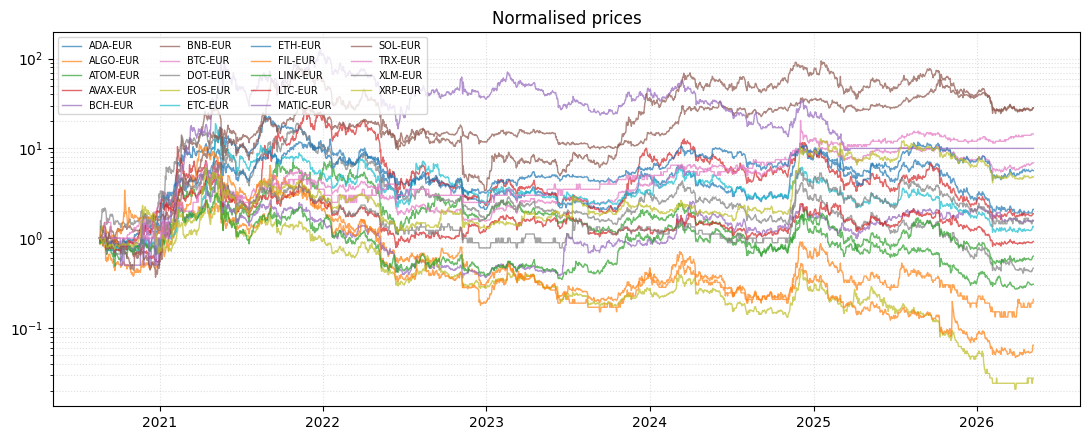

In [73]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for t in tickers:
    s = wide.select('date', (pl.col(t) / pl.col(t).first()).alias(t))
    ax.plot(s['date'], s[t], label=t, alpha=0.7, linewidth=1)
ax.set_yscale('log')
ax.set_title('Normalised prices')
ax.legend(ncol=4, fontsize=7, loc='upper left')
ax.grid(True, which='both', linestyle=':', alpha=0.4)
plt.tight_layout()

## 2.  Lead-lag signal via pairwise Levy area

We only ever store the **upper-triangular** $L_{ij}$ — there's no symmetric $\pm L_{ij}$ matrix anywhere.  Routing happens at trade time: the sign of each $L_{ij}$ tells us which side of the pair is the follower.

In [74]:
WINDOW = 120         # rolling Levy-area lookback (trading days)
REBAL  = '1d'      # rebalance frequency

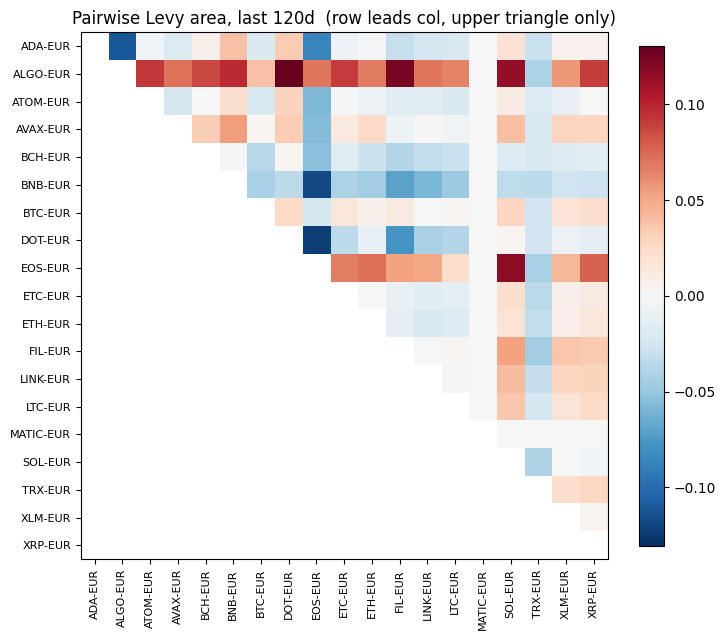

In [75]:
ll.plot_levy_triangle(wide, window=WINDOW)
plt.tight_layout()

Pair-trading weights: each ticker only earns exposure as the **follower** of pairs where the partner has just led.  The signal is built in three staged frames (Levy areas + level-1 cumulative log-returns → per-pair contributions → L1-normalised weights) so the polars expression DAG stays manageable for ~20 channels.

In [76]:
weights

date,ADA-EUR,ALGO-EUR,ATOM-EUR,AVAX-EUR,BCH-EUR,BNB-EUR,BTC-EUR,DOT-EUR,EOS-EUR,ETC-EUR,ETH-EUR,FIL-EUR,LINK-EUR,LTC-EUR,MATIC-EUR,SOL-EUR,TRX-EUR,XLM-EUR,XRP-EUR
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2020-08-20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-08-21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-08-22,0.104461,0.179973,0.114961,0.0,0.032815,0.038644,0.019825,0.002546,0.050386,0.043888,0.066953,0.0,0.161724,0.056991,0.0,0.08404,0.0,0.0,0.042793
2020-08-23,4.5053e-18,0.205762,0.253525,0.0,0.021966,0.024506,0.015198,0.0,0.027214,0.034889,0.051349,0.061744,0.067256,0.053462,0.0,0.139487,0.0,0.0,0.043642
2020-08-24,0.08156,0.181219,0.131826,0.0,0.035469,0.047441,0.019621,0.0,0.03713,0.038908,0.074446,0.058311,0.065155,0.061664,0.0,0.102253,0.0,0.0,0.064996
2020-08-25,9.5840e-19,0.234877,0.275061,0.0,-0.003727,0.006418,-0.002132,-0.05529,-0.002768,-0.002702,0.061754,-0.013198,0.107697,0.025416,0.0,0.200506,0.0,-0.007668,0.000785
2020-08-26,0.026511,0.133523,-0.033873,0.0,-0.000885,0.098455,0.01069,0.010413,-0.000817,0.002117,0.068999,-0.019215,0.239014,0.024455,0.0,0.326242,0.0,-0.003088,0.001704
2020-08-27,-0.024804,-0.018872,-0.11597,0.0,-0.008844,0.175228,-0.001002,-0.157922,-0.007322,-0.002987,0.031137,-0.054651,0.119584,-0.008026,0.0,0.258739,0.0,-0.003528,-0.011384
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…


In [77]:
weights = ll.signal(wide, window=WINDOW)

diag = weights.select(
    'date',
    sum_w   = pl.sum_horizontal(cs.numeric()),
    gross_w = pl.sum_horizontal(cs.numeric().abs()),
)
diag.tail()

date,sum_w,gross_w
date,f64,f64
2026-05-03,-0.994605,1.0
2026-05-04,-0.994588,1.0
2026-05-05,-0.993652,1.0
2026-05-06,-0.99443,1.0
2026-05-07,-0.990674,1.0


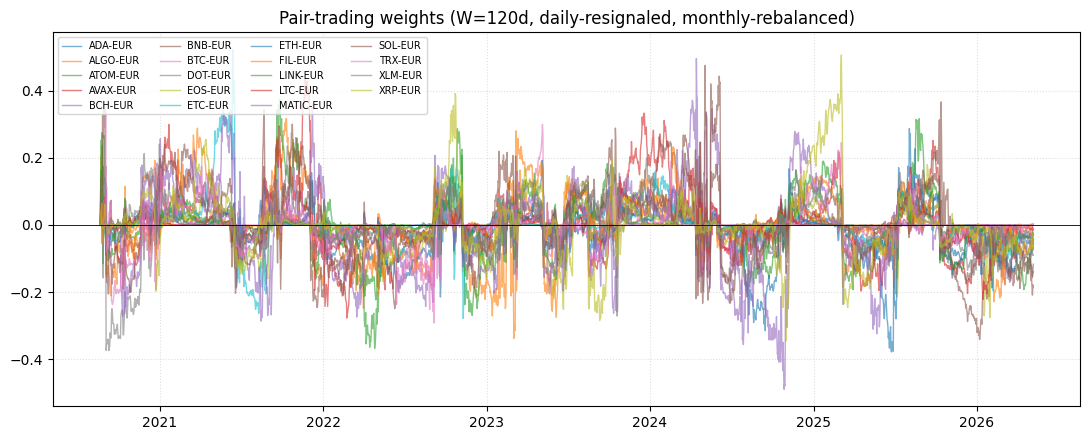

In [78]:
# Per-asset weight time series — most rows will be near zero for a given
# ticker, popping up only when one of its leaders has actually ticked.
fig, ax = plt.subplots(figsize=(11, 4.5))
for t in tickers:
    ax.plot(weights['date'], weights[t], label=t, alpha=0.6, linewidth=1)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_title(f'Pair-trading weights (W={WINDOW}d, daily-resignaled, monthly-rebalanced)')
ax.legend(ncol=4, fontsize=7, loc='upper left')
ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()

## 4.  Backtest

Apply weights with **monthly rebalancing** and a single-row shift (no look-ahead).  Compare against an **equally-weighted buy-and-hold** baseline so we don't claim wins just because crypto rallied.

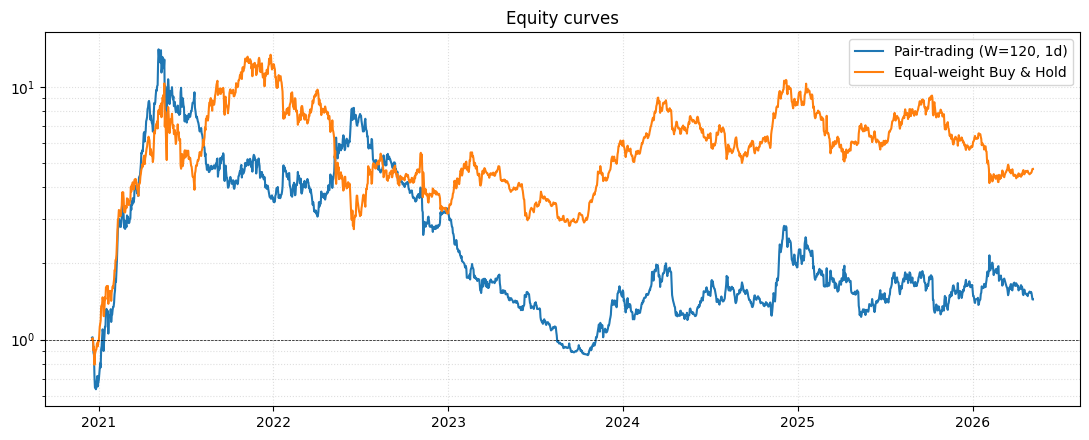

In [79]:
ll_pnl = ll.backtest(wide, weights, rebal_every=REBAL)
bh_pnl = ll.buy_and_hold(wide)

# Drop the burn-in (everything before WINDOW)
first_valid = wide['date'][WINDOW]
ll_pnl_v = ll_pnl.filter(pl.col('date') >= first_valid).with_columns(
    equity=(pl.col('pnl') + 1.0).cum_prod()
)
bh_pnl_v = bh_pnl.filter(pl.col('date') >= first_valid).with_columns(
    equity=pl.col('equity') / pl.col('equity').first()
)

ll.plot_equity_curves({
    f'Pair-trading (W={WINDOW}, {REBAL})': ll_pnl_v,
    'Equal-weight Buy & Hold': bh_pnl_v,
}, title='Equity curves')
plt.tight_layout()

In [80]:
stats = pl.DataFrame([
    {'strategy': 'Pair-trading', **ll.perf_summary(ll_pnl_v, periods_per_year=365)},
    {'strategy': 'Buy-and-Hold', **ll.perf_summary(bh_pnl_v, periods_per_year=365)},
])
stats

strategy,cagr,vol,sharpe,max_dd
str,f64,f64,f64,f64
"""Pair-trading""",0.070145,0.80344,0.485554,-0.938395
"""Buy-and-Hold""",0.338255,0.769758,0.765576,-0.796038


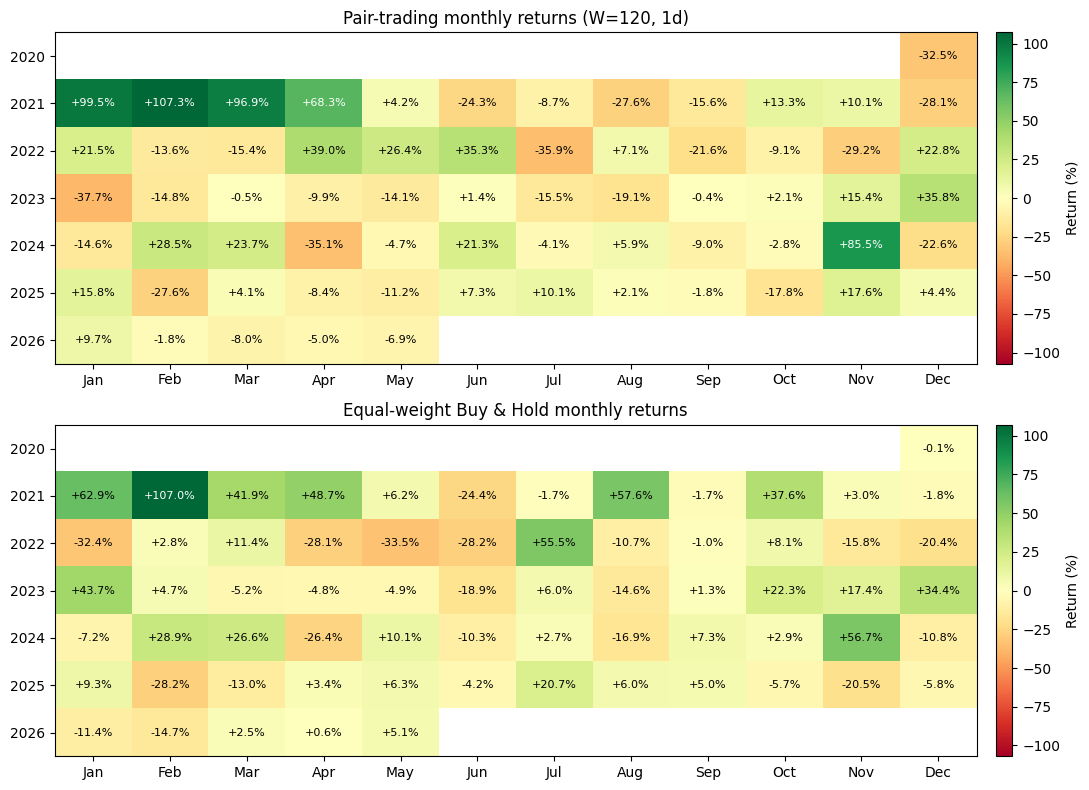

In [81]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8))
ll.plot_monthly_returns(ll_pnl_v, title=f'Pair-trading monthly returns (W={WINDOW}, {REBAL})', ax=axes[0])
ll.plot_monthly_returns(bh_pnl_v, title='Equal-weight Buy & Hold monthly returns', ax=axes[1])
plt.tight_layout()

### Optional: parameter sweep over the lookback window

window,cagr,vol,sharpe,max_dd
i64,f64,f64,f64,f64
30,-0.272067,0.856288,0.07594,-0.89537
60,0.338435,0.818361,0.768818,-0.809322
90,-0.209468,0.812901,0.123949,-0.970031
120,0.070145,0.80344,0.485554,-0.938395


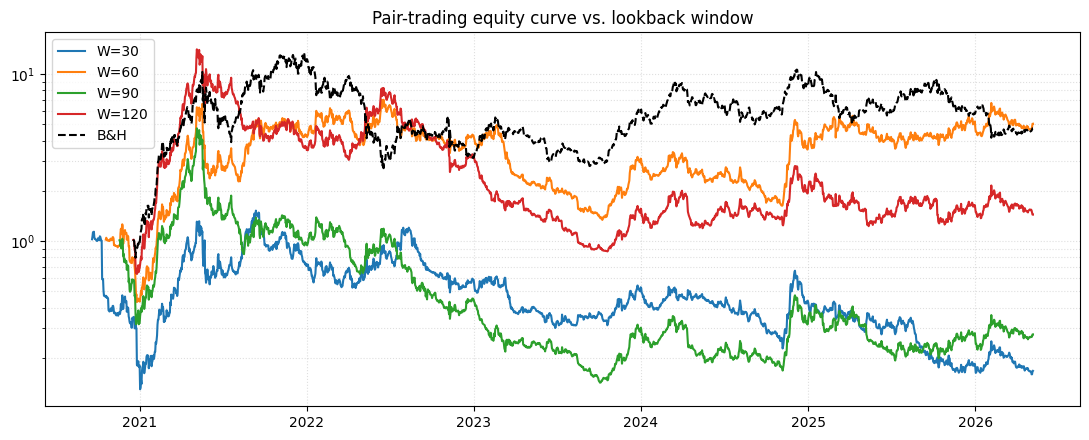

In [82]:
sweep = []
for w in (30, 60, 90, 120):
    weights_w = ll.signal(wide, window=w)
    pnl_w = ll.backtest(wide, weights_w, rebal_every=REBAL).filter(pl.col('date') >= wide['date'][w])
    pnl_w = pnl_w.with_columns(equity=(pl.col('pnl') + 1.0).cum_prod())
    sweep.append((w, pnl_w, ll.perf_summary(pnl_w, periods_per_year=365)))

fig, ax = plt.subplots(figsize=(11, 4.5))
for w, pnl_w, _ in sweep:
    ax.plot(pnl_w['date'], pnl_w['equity'], label=f'W={w}')
ax.plot(bh_pnl_v['date'], bh_pnl_v['equity'], label='B&H', linestyle='--', color='black')
ax.set_yscale('log'); ax.set_title('Pair-trading equity curve vs. lookback window')
ax.legend(); ax.grid(True, which='both', linestyle=':', alpha=0.4)
plt.tight_layout()

pl.DataFrame([{'window': w, **s} for w, _, s in sweep])